# 9. Quality control and failure modes

When a case looks wrong, where to look first. Each section shows the check the pipeline makes or a picture that exposes the problem, using the fixture case and a few deliberately broken inputs.

In [1]:
import numpy as np, nibabel as nib, matplotlib.pyplot as plt
from arterial_nb import *
from arterial.io.load_and_save_operations import load_json, load_pickle, load_numpy
from arterial.centerline_extraction.utils import volume_sanity_check, get_bounding_box_limits_3d

segmentation = nib.load(fixture("segmentation.nii.gz")); seg = np.asarray(segmentation.dataobj)
voxel_mm3 = float(np.prod(np.abs(np.diag(segmentation.affine)[:3])))


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



## 1. Is the segmentation plausible?

Before any centerline work the mask must have a sensible volume and extent. The checks were tuned on real head-and-neck CTAs; a mask that fails them is almost always an artefact, a cropped scan or the wrong image.

In [2]:
lo_r, hi_r, lo_a, hi_a, lo_s, hi_s = get_bounding_box_limits_3d(seg)
rows = [["segmentation volume (cm3)", round(seg.sum() * voxel_mm3 / 1000, 1), "> 35"],
        ["bounding box volume (cm3)", round((hi_r - lo_r) * (hi_a - lo_a) * (hi_s - lo_s) * voxel_mm3 / 1000, 1), "2,500 to 35,000"]]
table(rows, columns=["check", "this case", "expected"])

,check,this case,expected
0,segmentation volume (cm3),101.9,> 35
1,bounding box volume (cm3),5618.4,"2,500 to 35,000"


In [3]:
examples = {"healthy mask": seg, "cropped to the neck only": seg * (np.arange(seg.shape[2]) < 300)[None, None, :], "almost empty": (seg * (np.random.default_rng(0).random(seg.shape) < 0.02)).astype(seg.dtype)}
for name, mask in examples.items():
    try:
        volume_sanity_check(mask, segmentation.affine); print(f"{name:28s} OK")
    except ValueError as error:
        print(f"{name:28s} REJECTED: {error}")

healthy mask                 OK
cropped to the neck only     REJECTED: Bounding box volume is too small: 1623082.89 mm3


almost empty                 REJECTED: Segmentation volume is too small: 2061.23 mm3


## 2. Fragmented masks

Many small islands mean a noisy segmentation. Islands below the size threshold are dropped, but if the *main* tree is broken into pieces the centerlines will be too, and the labelling will see disconnected segments.

43 islands; largest 838292 voxels; 36 below 1000 voxels


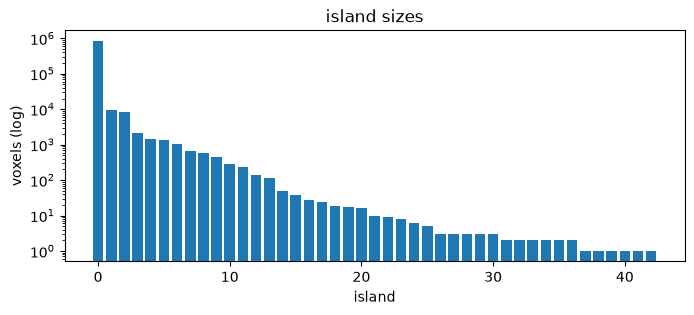

In [4]:
from skimage import measure
labels = measure.label(seg)
sizes = sorted(np.bincount(labels.ravel())[1:], reverse=True)   # skip the background
print(f"{len(sizes)} islands; largest {sizes[0]} voxels; {sum(1 for s in sizes if s < 1000)} below 1000 voxels")
plt.figure(figsize=(8, 3)); plt.bar(range(len(sizes)), sizes); plt.yscale("log"); plt.xlabel("island"); plt.ylabel("voxels (log)"); plt.title("island sizes");

## 3. Did the centerlines cover the tree?

Compare the segments array against the mask: long stretches of vessel without a centerline usually mean an endpoint was missed. Endpoints are saved per island, so count them.

In [5]:
import glob, os
segments = load_numpy(derived("centerline_segments_array.npy"))
endpoint_files = sorted(glob.glob(os.path.join(derived("endpoints"), "endpoints_*.json")))
rows = [[os.path.basename(f), len(load_json(f)["markups"][0]["controlPoints"])] for f in endpoint_files]
table(rows + [["segments in the array", len(segments)]], columns=["", "count"])

,,count
0,endpoints_0.json,12
1,endpoints_1.json,7
2,endpoints_2.json,5
3,segments in the array,28


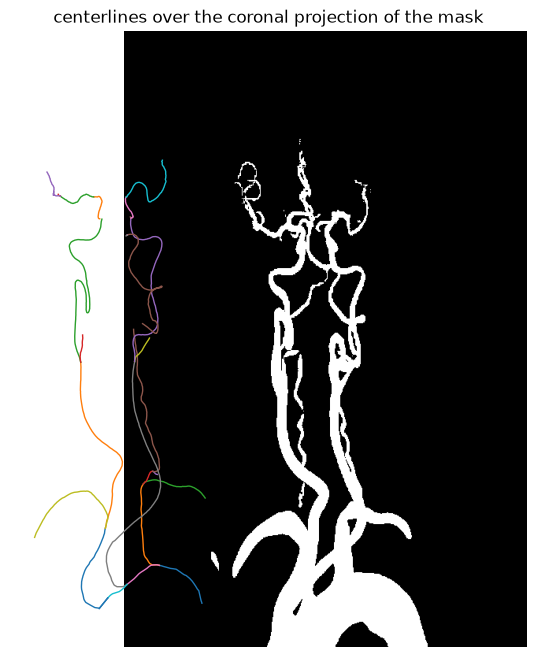

In [6]:
mip = seg.max(axis=1)
fig, ax = plt.subplots(figsize=(7, 8)); ax.imshow(mip.T, cmap="gray", origin="lower")
inv = np.linalg.inv(segmentation.affine)
for coords in segments[:, 0]:
    ijk = (inv @ np.c_[coords, np.ones(len(coords))].T).T
    ax.plot(ijk[:, 0], ijk[:, 2], linewidth=1)
ax.set_title("centerlines over the coronal projection of the mask"); ax.axis("off");

## 4. Labelling that does not add up

A tree should contain one aorta and the great vessels once each. Duplicated or missing names point at a wrong bifurcation upstream.

In [7]:
pred = load_pickle(derived("segments_graph_pred.pickle"))
counts = {}
for _, _, d in pred.edges(data=True):
    counts[d["vessel_type_name"]] = counts.get(d["vessel_type_name"], 0) + 1
expected_once = ["AA", "BT", "LCCA", "LSA", "RCCA", "RSA"]
table([[n, counts.get(n, 0), "" if counts.get(n, 0) == 1 else "check"] for n in expected_once] + [[n, c, ""] for n, c in counts.items() if n not in expected_once],
      columns=["vessel", "segments", ""])

,vessel,segments,
0,AA,4,check
1,BT,2,check
2,LCCA,1,
3,LSA,1,
4,RCCA,1,
5,RSA,1,
6,LVA,3,
7,other,9,
8,LECA,3,
9,LICA,1,


## 5. Degenerate pathways

Access prediction refuses a pathway that collapsed to a single segment. The sanity check used during feature extraction is the same idea at graph level.

In [8]:
from arterial.access_prediction.utils import supersegment_sanity_check
supersegment = load_pickle(derived("supersegments", "femoral + left + anterior.pickle"))
tiny = supersegment.subgraph(list(supersegment.nodes)[:5]).copy()
print("real pathway :", supersegment_sanity_check(supersegment))
print("5-node stub  :", supersegment_sanity_check(tiny))

real pathway : True
5-node stub  : False


## 6. Time

Stage timings on a healthy GPU server for the fixture case. If segmentation takes tens of minutes instead of one, the GPU is idle or throttled: look at `nvidia-smi` while `predicting` is printed, not at the code.

In [9]:
table([["segmentation, fast mode", "~45 s"], ["segmentation, full mode", "~3 min"], ["centerlines, fast mode", "~20 s"], ["centerlines, full mode", "~20 s to several minutes"],
       ["landmark detection", "~1 min"], ["vessel labelling", "seconds"], ["feature extraction", "~1 min"], ["access prediction", "seconds"]], columns=["stage", "typical duration"])

,stage,typical duration
0,"segmentation, fast mode",~45 s
1,"segmentation, full mode",~3 min
2,"centerlines, fast mode",~20 s
3,"centerlines, full mode",~20 s to several minutes
4,landmark detection,~1 min
5,vessel labelling,seconds
6,feature extraction,~1 min
7,access prediction,seconds


## Messages worth knowing

| message | meaning |
|---|---|
| `Segmentation volume is too small` | mask rejected before centerline extraction; check the segmentation overlay |
| `can't reconstruct new profile` (VMTK) | harmless warning during endpoint detection |
| `Branch model could not be extracted for first model` | VMTK failed on the main island; the stage stops |
| `Segmentation not found. Falling back to CTA-only model` | landmark detection ran without its second input channel |
| `Supersegment has ... 0 edges` | a pathway collapsed; labelling upstream needs a look |
| `Checksum mismatch` (download) | corrupt weights archive; rerun the download |